In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv("Flight_Fare_Prediction.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [ ]:
# removing the unnecessary column
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
# checking the null values
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


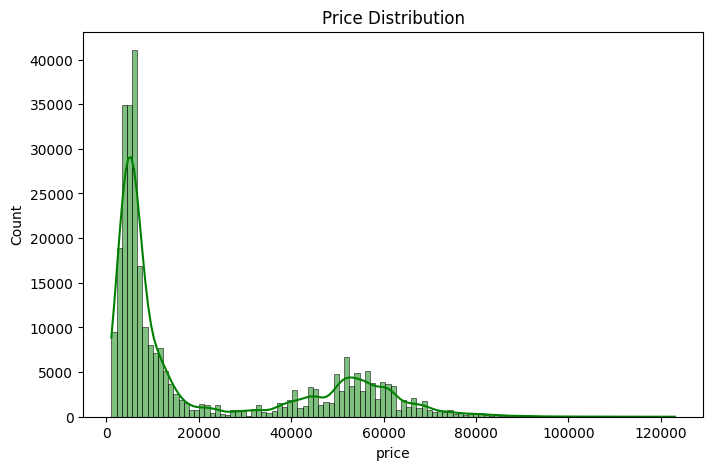

In [ ]:
# price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='green')
plt.title("Price Distribution")
plt.show()

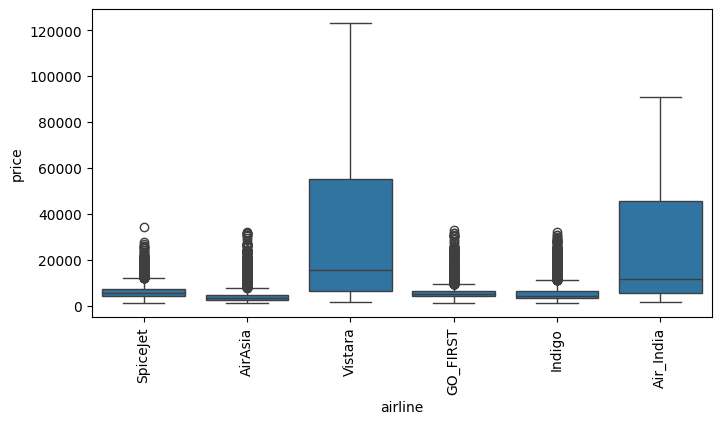

In [ ]:
# Price vs Airline
plt.figure(figsize=(8,4))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=90)
plt.show()

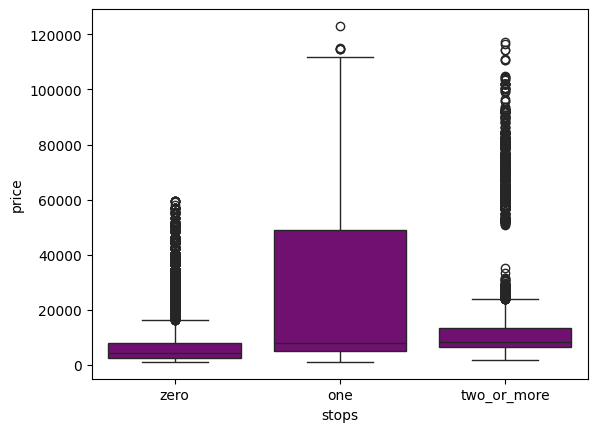

In [ ]:
# Price vs Stops
sns.boxplot(x='stops', y='price', data=df, color = 'purple')
plt.show()

In [ ]:
# Encoding Categorical Variables
le = LabelEncoder()

categorical_columns = [
'airline',
'flight',
'source_city',
'departure_time',
'stops',
'arrival_time',
'destination_city',
'class'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,681,0,2,2,5,5,1,2.17,1.0,5953.0
1,4,661,0,1,2,4,5,1,2.33,1.0,5953.0
2,0,585,0,1,2,1,5,1,2.17,1.0,5956.0
3,5,786,0,4,2,0,5,1,2.25,1.0,5955.0
4,5,776,0,4,2,4,5,1,2.33,1.0,5955.0


In [ ]:
# drop flight column
df.drop(columns=['flight'], inplace=True)

In [ ]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,0,2,2,5,5,1,2.17,1.0,5953.0
1,4,0,1,2,4,5,1,2.33,1.0,5953.0
2,0,0,1,2,1,5,1,2.17,1.0,5956.0
3,5,0,4,2,0,5,1,2.25,1.0,5955.0
4,5,0,4,2,4,5,1,2.33,1.0,5955.0


In [ ]:
# features and target
X = df.drop('price', axis=1)
y = df['price']

# Drop rows where 'y' is NaN to ensure consistency
data = pd.concat([X, y], axis=1).dropna()
X = data.drop('price', axis=1)
y = data['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ML Model - Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)


In [ ]:
# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [ ]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
# Evaluating the model
def evaluate(y_test, pred):

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)


In [ ]:
# evaluating linear regression
evaluate(y_test, pred_lr)

MAE: 4622.187103361371
RMSE: 7013.558484851851
R2 Score: 0.9045747930770209


In [ ]:
# evaluating decision tree
evaluate(y_test, pred_dt)

MAE: 890.3888463182911
RMSE: 2978.6898537158286
R2 Score: 0.9827877820449549


In [ ]:
# evaluating random forest
evaluate(y_test, pred_rf)

MAE: 862.9665722015187
RMSE: 2319.161587158152
R2 Score: 0.98956606125345


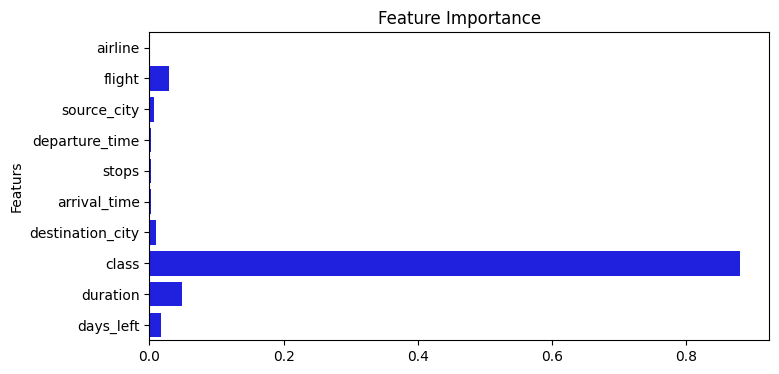

In [ ]:
# interpreting the important fetures
importances = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,4))
sns.barplot(x=importances, y=features, color = 'blue')
plt.ylabel("Featurs")
plt.title("Feature Importance")
plt.show()